# Wstęp
Laboratorium 5 stanowi wprowadzenie w tematykę sieci konwolucyjnych. Sieci te wykorzystują, jak sama nazwa wskazuje, operację konwolucji (splotu) co pozwala na uwzględnienie informacji o lokalnym sąsiedztwie przestrzennym w przetwarzanych danych. W przypadku obrazów, jest to sąsiedztwo pikseli w dwuwymiarowej przestrzeni obrazu.

# Cel  ćwiczenia

Celem ćwiczenia jest zapoznianie z:

*   operacją konwolucji 2D i jej implementacją w torchu
*   warstwami konwolucyjnymi i ich parametrami
*   operacjami poolingu
*   prostymi sieciami konwolucyjnymi w klasyfikacji obrazu

# Konwolucja 2D

Najpierw wprowadzimy operację konwolucji. Konwolucja 2D przyjmuje na wejściu tensory o kształcie `(B,C,H,W)` - batch, channel, width, height. Kanały nazywamy też *mapami cech*, jako że w warstwach innych niż wejściowa są to w dalszym ciągu dwuwymiarowe "obrazki", ale odpowiadające już nie wprost kanałom RGB, ale pewnym cechom wydobywanym z mapy cech na wejściu przez uczące się filtry.

Tensor filtrów ma wymiary `(I,O,H,W)` - liczba kanałów warstwy wejściowej, liczba kanałów warstwy wyjściowej, wysokość i szerokość filtra. Możemy pomyśleć o tym przez analogię z warstwą w pełni połączoną: tam, element tensora wag `weights[i,j]` był jedną liczbą i odpowiadał połączeniu i-tego wejścia do j-tego wyjścia. W konwolucji, `weights[i,j]`  będzie odpowiadać połączeniu i-tej mapy cech do j-tej mapy cech, będzie jednak całą macierzą, ponieważ dla każdego połączenia we-wy map cech uczymy dwuwymiarowego filtra.

Dla przykładu, zaimplementujmy filtr rozmywający obraz RGB - każdy kanał z osobna. Filtr rozmywający jeden kanał definiuje `filter`, a ponieważ chcemy uzyskać połączenie tylko kanałów wejściowych do wyjściowych: R do R, G do G, B do B, a ponieważ dla każdego z tych połączeń filtr będzie taki sam, możemy po prostu wymnożyć go przez tensor `(3,3,1,1)`, utworzony z macierzy jednostkowej. W torchu taką macierz zwraca metoda `eye`.

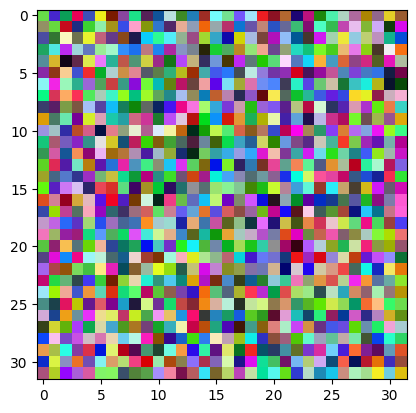

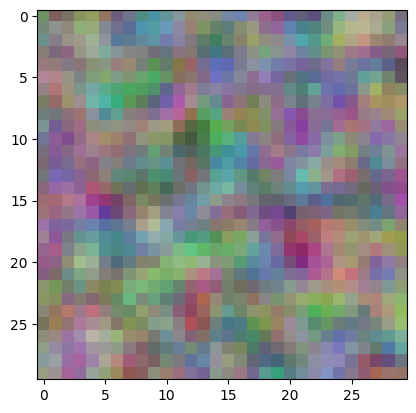

In [1]:
import torch
from matplotlib import pyplot as plt

tensor = torch.rand((1,3,32,32))

channel_connections = torch.eye(3)

filter = torch.tensor(
    [[0.1,0.1,0.1],
    [0.1,0.2,0.1],
    [0.1,0.1,0.1]]
)

blur = channel_connections.view(3,3,1,1)*filter

plt.imshow(tensor[0].permute(1,2,0))
plt.show()

blurred = torch.nn.functional.conv2d(tensor,blur)

plt.imshow(blurred[0].permute(1,2,0))
plt.show()


# Zadanie 1

Zdefiniuj tensor 3x3x3x3 `rg_blur_to_b`.

Zakładając że mamy do czynienia z obrazem RGB, konwolucja na wyjściu zwracać ma obraz RGB, gdzie

* w kanale B zwracamy uśrednienie rozmytych (analogiczne jak wyżej) kanałów R, G obrazka wejściowego
* kanały R i G na wyjściu są zerami


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.0..0.9999807].


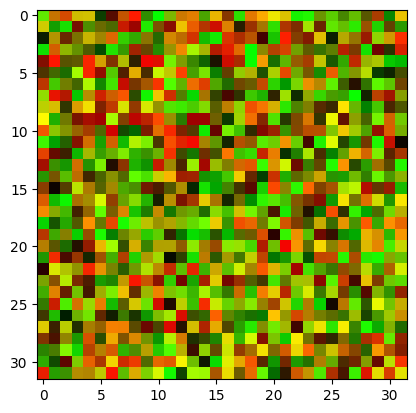

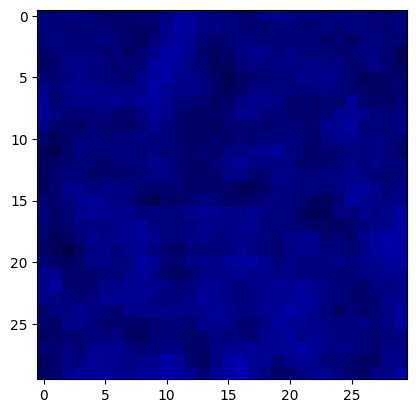

In [2]:
tensor = torch.rand((10,3,32,32))
tensor[:,2] = -7

filter = torch.tensor(
    [[0.1,0.1,0.1],
    [0.1,0.2,0.1],
    [0.1,0.1,0.1]]
)

zeros = torch.zeros(3,3)

# Tensor wag ma kształt (O, I, H, W) = (3, 3, 3, 3)
# Wyjście: kanały R (0) i G (1) = zera,
# kanał B (2) = 0.5 * blur(R) + 0.5 * blur(G) + 0 * B
rg_blur_to_b = torch.stack([
    torch.stack([zeros,      zeros,      zeros]),       # out R: zera
    torch.stack([zeros,      zeros,      zeros]),       # out G: zera
    torch.stack([0.5*filter, 0.5*filter, zeros]),       # out B: średnia rozmytych R i G
])

blurred = torch.nn.functional.conv2d(tensor, rg_blur_to_b)

plt.imshow(tensor[0].permute(1,2,0))
plt.show()

plt.imshow(blurred[0].permute(1,2,0))
plt.show()


# Warstwa konwolucyjna

W sieci konwolucyjnej będziemy wykorzystywać operację konwolucji tak jak opisane powyżej, w której uczone są tensor filtrów i bias dodawany do tensora na wyjściu. Warstwę z uczonymi parametrami definiuje klasa:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Pokrótce wyjaśnijmy parametry tej klasy na przykładzie filtra 2x2.

Poniższy obrazek reprezentuje lewy, górny róg mapy cech:

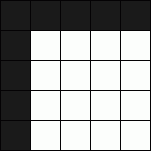

Na czerwono zaznaczymy pierwszy krok filtra przechodzącego po obrazie, na niebiesko drugi. Kolor fioletowy oznaczać będzie, że pola obejmowane przez filtry się pokrywają. Oznaczone pola przekładają się na dwa pierwsze piksele w wyjściowej mapie cech. Filtr 2x2 przy domyślnych parametrach będzie przechodził po obrazie następująco:

--------- Wejście ---------------------  Wyjście ----------

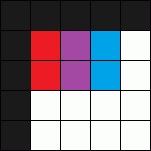
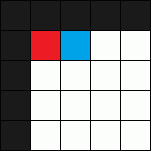


W kodzie deklarujemy w pierwszych trzech argumentach konstruktora `torch.nn.Conv2d`: liczbę kanałów wejściowych, liczbę kanałów wyjściowych, rozmiar filtra. Przy okazji, torchowa konwencja - aby podać rozmiar okna 2d możemy użyć jako argumentu zarówno krotki (x,y) jak i jednej liczby całkowitej, definiującej okno kwadratowe (x,x).

In [3]:
data_batch = torch.zeros(10,16,32,32)

#deklaracja warstwy: 16 kanałów wejściowych, 32 wyjściowych, filtr 2x2
conv_layer = torch.nn.Conv2d(16,32,2)

conv_layer(data_batch).shape

torch.Size([10, 32, 31, 31])

Jak widać, w wymiarach szerokości i wysokości, mapy cech zmniejszają się o 1.

Parametr `padding` pozwala na dodanie dodatkowych pikseli na krawędzi obrazka. Używany jest, aby zachować stałą szerokość i wysokość mapy cech po konwolucji. Dla `padding=1` pola obejmowane przez filtr będą wyglądać tak:

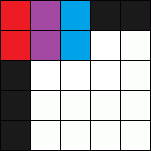

In [4]:
data_batch = torch.zeros(10,16,32,32)

conv_layer = torch.nn.Conv2d(16,16,2,padding=1)
print(conv_layer(data_batch).shape)

conv_layer = torch.nn.Conv2d(16,16,3,padding=1)
print(conv_layer(data_batch).shape)

torch.Size([10, 16, 33, 33])
torch.Size([10, 16, 32, 32])


Zauważ, że ze względu na symetryczny padding (dodawanie pikseli po obu stronach obrazu wejściowego) operacja zachowuje wysokość i szerokość tylko dla filtra o nieparzystym rozmiarze.

Parametr `stride` to krok filtra. Używany jest aby zredukować wymiary szerokości i wysokości pomiędzy kolejnymi warstwami konwolucyjnymi. `stride=2` daje nam downsampling do dwukrotnie mniejszej rozdzielczości, z wykorzystaniem uczącej się warstwy która może jednocześnie zmienić liczbę kanałów:

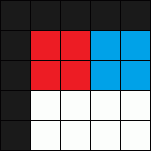


In [5]:
data_batch = torch.zeros(10,16,32,32)
conv_layer = torch.nn.Conv2d(16,16,2,stride=2)

conv_layer(data_batch).shape

torch.Size([10, 16, 16, 16])

Parametr `dilation` określa rozstaw filtra. Pozwala to obejmować filtrem piksele odległe od siebie o pewną stałą wartość. Szczególnie istotnym wykorzystaniem tego parametru jest użycie sekwencji warstw, w których kolejne wartości `dilation` to kolejne potęgi 2 - efektywnie skalując rozmiar pola obejmowanego przez całą architekturę wykładniczo z głębokością. Dla `dilation=2`:

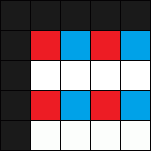

In [6]:
data_batch = torch.zeros(10,16,32,32)
conv_layer = torch.nn.Conv2d(16,16,2,dilation=2)

conv_layer(data_batch).shape

torch.Size([10, 16, 30, 30])

#Pooling

Zanim z warstw zbudujemy sieć, warto jeszcze wprowadzić operacje: poolingu i spłaszczania.

In [7]:
pool_layer =  torch.nn.MaxPool2d(2) #okno o stałym rozmiarze 2x2
adaptive_pool_layer = torch.nn.AdaptiveAvgPool2d((2,4)) #pooling adaptacyny
flatten_layer = torch.nn.Flatten()

data_batch = torch.zeros(10,3,128,128)
pool_layer(data_batch).shape, adaptive_pool_layer(data_batch).shape, flatten_layer(data_batch).shape

(torch.Size([10, 3, 64, 64]),
 torch.Size([10, 3, 2, 4]),
 torch.Size([10, 49152]))

Dwa standardowe typy poolingu to Max i Average pooling - zwracające odpowiednio maximum lub średnią z okna pooling.

Pooling o stałym rozmiarze okna pozwala nam na downsampling w wymiarach szerokości i wysokości bez potrzeby dodawania uczącej się warstwy. Przykładowo, okno 2x2 da nam redukcję szerokości i wysokości o dwa razy.

Pooling o adaptacyjnym rozmiarze okna pozwala na sprowadzenie wyniku konwolucji do stałego, zadanego rozmiaru wysokość/szerokość, co jest szczególnie przydatne jeśli chcemy przetwarzać obrazy o różnych rozmiarach. Zwykle wykorzystuje się go tylko w jednym miejscu, przed spłaszczeniem i ostatnią warstwą w pełni połączoną. Adaptacyjna warstwa poolingu z parametrem 2 bedzie redukować rozmiar w wymiarach wysokość, szerokośc do 2 na 2 - samodzielnie wyliczając dla każdego wejścia rozmiar okna potrzebny, żeby takie wyjście uzyskać.

Spłaszczanie zaś, jak sama nazwa wskazuje spłaszcza kształt tensora z (B, C, H, W) do (B, C\*H\*W)





Aby przejść do budowania i uczenia sieci konwolucyjnych, wczytamy zbiór CIFAR10. Zdefiniujemy też funkcje wykorzystane już na poprzednich laboratoriach:

In [8]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm import tqdm

transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch.cuda())
        all += len(y_pred)
        loss += loss_fn(y_pred, y_batch.cuda()).sum()
        correct += count_correct(y_pred, y_batch.cuda())
    return loss / all, correct / all

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: str = True
):
  for epoch in range(epochs):
      for X_batch, y_batch in tqdm(train_dl):
          y_pred = model(X_batch.cuda())
          loss = loss_fn(y_pred, y_batch.cuda())

          loss.backward()
          optimiser.step()
          optimiser.zero_grad()

      if print_metrics:
          model.eval()
          with torch.no_grad():
              train_loss, train_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=train_dl
              )
              val_loss, val_acc = validate(
                  model=model, loss_fn=loss_fn, dataloader=val_dl
              )
              print(
                  f"Epoch {epoch}: "
                  f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                  f"validation loss = {val_loss:.3f} (acc: {val_acc:.3f})"
              )

/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Zdefiniujmy teraz prostą sieć konwolucyjną.

# Zadanie 2

Uzupełnij kod klasy `SimpleCNN` tak, aby warstwy konwolucyjne nie zmieniały szerokości i wysokości mapy cech na wyjściu oraz aby wyjście w postaci tensora miało kształt zgodny z pożądanym `(batch_size, labels)`. Użyj rozmiaru filtra 3x3.

Zauważ, że o ile warstwy konwolucyjne nie muszą znać rozmiaru obrazu, o tyle spłaszczenie obrazu i podanie do warstwy w pełni połączonej wymusza na nas zdefiniowanie tego rozmiaru z góry. Sieć zbudowana w ten sposób przetwarzać będzie tylko obrazy o stałej szerokości i wysokości. Na potrzeby zadania, sieć ma być dostosowana do zbioru CIFAR: przyjmować obrazy RGB, 32x32 na wejściu i zwracać 10-elementowy wektor na wyjściu.

In [9]:
class SimpleCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int):
    super().__init__()
    # Wejście CIFAR: (B, 3, 32, 32)
    # conv z padding=1 dla filtra 3x3 zachowuje H, W
    # maxpool(2) redukuje H, W z 32 do 16
    # przed linear: channels * 16 * 16
    self.model = torch.nn.Sequential()
    self.model.add_module("conv_1", torch.nn.Conv2d(3, channels, kernel_size=3, padding=1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("max_pool", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2", torch.nn.Conv2d(channels, channels, kernel_size=3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear(channels * 16 * 16, labels))

  def forward(self, x):
    return self.model(x)


Zweryfikuj, że sieć zwraca wlaściwy wymiar wyjścia i zmierz czas przetwarzania konwolucji na CPU i GPU

In [10]:
cnn_model = SimpleCNN(16, 10)
out = cnn_model(torch.zeros(128,3,32,32))
assert out.shape==(128,10)

%timeit cnn_model(torch.zeros(128,3,32,32))
cnn_model.cuda()
%timeit cnn_model(torch.zeros(128,3,32,32).cuda())


5.6 ms ± 150 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
964 μs ± 416 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


Sprawdźmy, że jesteśmy w stanie uczyć tę sieć:

In [11]:
optimizer = optim.Adam(cnn_model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()
fit(cnn_model, optimizer, loss_fn, train_dl, test_dl, 5, True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [00:13<00:00, 119.07it/s]


Epoch 0: train loss = 0.038 (acc: 0.583), validation loss = 0.039 (acc: 0.566)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [00:12<00:00, 123.33it/s]


Epoch 1: train loss = 0.034 (acc: 0.616), validation loss = 0.036 (acc: 0.594)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [00:13<00:00, 118.70it/s]


Epoch 2: train loss = 0.033 (acc: 0.632), validation loss = 0.035 (acc: 0.601)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [00:14<00:00, 111.55it/s]


Epoch 3: train loss = 0.029 (acc: 0.674), validation loss = 0.033 (acc: 0.635)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [00:15<00:00, 102.44it/s]


Epoch 4: train loss = 0.029 (acc: 0.678), validation loss = 0.033 (acc: 0.627)


# Zadanie 3

Zdefiniuj klasę `CNN`, sieć o strukturze

*   warstwa wejściowa in_conv o rozmiarze filtra 1x1 (transformuje liczbę kanałów z 3 na docelową)
*   sekwencja warstw konwolucyjnych z downsamplingiem 2x w wymiarach przestrzennych w każdej warstwie (patrz niżej)
*   spłaszczenie wyniku do wektora
*   warstwa w pełni połączona

Klasa powinna być parametryzowalna tak, aby

*   umożliwić wybór rozmiaru filtra w warstwach konwolucji oprócz in_conv
*   umożliwić wybór zarówno liczby warstw, jak i liczby kanałów w poszczególnych warstwach konwolucyjnych
*   umożliwić wybór między downsamplingiem poprzez dodanie warstw poolingu po każdej warstwie, a poprzez ustawienie paramteru stride (zachowujemy **tę samą liczbę warstw konwolucyjnych**, warstwa in_conv nie dokonuje downsamplingu)




In [12]:
class CNN(torch.nn.Module):
  def __init__(
      self,
      labels: int,
      kernel_size: int,
      channels: list,
      downsample: str = "stride",   # "stride" lub "pool"
      input_channels: int = 3,
      input_size: int = 32,
  ):
    super().__init__()
    assert downsample in ("stride", "pool"), "downsample musi być 'stride' lub 'pool'"
    # padding = k//2 zachowuje H, W dla nieparzystych rozmiarów filtra
    padding = kernel_size // 2

    layers = []
    # in_conv: filtr 1x1, transformuje 3 -> channels[0], BEZ downsamplingu
    layers.append(torch.nn.Conv2d(input_channels, channels[0], kernel_size=1))
    layers.append(torch.nn.ReLU())

    # sekwencja warstw konwolucyjnych: każda dokonuje downsamplingu 2x
    prev = channels[0]
    for c in channels:
      if downsample == "stride":
        layers.append(torch.nn.Conv2d(
            prev, c, kernel_size=kernel_size, padding=padding, stride=2
        ))
      else:  # pool
        layers.append(torch.nn.Conv2d(
            prev, c, kernel_size=kernel_size, padding=padding
        ))
        layers.append(torch.nn.MaxPool2d(2))
      layers.append(torch.nn.ReLU())
      prev = c

    # po len(channels) downsamplingach: rozmiar przestrzenny = input_size / 2^n
    out_size = input_size // (2 ** len(channels))
    layers.append(torch.nn.Flatten())
    layers.append(torch.nn.Linear(channels[-1] * out_size * out_size, labels))

    self.model = torch.nn.Sequential(*layers)

  def forward(self, x):
    return self.model(x)


Zweryfikuj działanie implementacji:

In [13]:
dummy_data = torch.zeros(37,3,32,32)

# 15 etykiet, filtr 5x5, 3 warstwy conv (16, 32, 64), downsampling warstwą konwolucyjną (stride=2)
cnn_model = CNN(labels=15, kernel_size=5, channels=[16, 32, 64], downsample="stride")
assert cnn_model(dummy_data).shape == (37, 15)

# 10 etykiet, filtr 3x3, 4 warstwy conv (8, 16, 32, 64), downsampling warstwą poolingu
cnn_model = CNN(labels=10, kernel_size=3, channels=[8, 16, 32, 64], downsample="pool")
assert cnn_model(dummy_data).shape == (37, 10)

%timeit cnn_model(torch.zeros(128,3,32,32))
cnn_model.cuda()
%timeit cnn_model(torch.zeros(128,3,32,32).cuda())


7.29 ms ± 728 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.69 ms ± 70.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Zadanie 4

Wykorzystaj zdefiniowaną klasę, aby przeprowadzić porównania:

1.   Uczenie z filtrem 3x3 a 5x5
2.   Uczenie z Max Pooling a warstwą konwolucyjną do downsamplingu
3.   Uczenie z trzema warstwami o rozmiarach 16,32,64, a uczenie z trzema warstwami o rozmiarach 32,32,32

Porównaj w kontekście metryki F-score, wyrysuj krzywe uczenia. Możesz tu korzystać z kodu napisanego na poprzednich laboratoriach. Przy problemach z mocą obliczeniową, dokonaj trenowania na mniejszym podzbiorze zbioru treningowego (np. 10%).

In [17]:
import copy
import numpy as np
from torch.utils.data import Subset
from sklearn.metrics import f1_score

rng = np.random.default_rng(42)
subset_idx = rng.choice(len(train_ds), size=len(train_ds) // 2, replace=False).tolist()
train_subset = Subset(train_ds, subset_idx)
train_dl_small = DataLoader(train_subset, batch_size=64, shuffle=True, pin_memory=True)


def evaluate(model, loss_fn, dataloader):
    model.eval()
    total_loss, total_n = 0.0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            y_pred = model(X_batch.cuda())
            bs = len(y_pred)
            total_loss += loss_fn(y_pred, y_batch.cuda()).item() * bs
            total_n += bs
            all_preds.append(torch.argmax(y_pred, dim=1).cpu().numpy())
            all_labels.append(y_batch.numpy())
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    return total_loss / total_n, f1_score(labels, preds, average="macro")


def fit_with_history(model, optimizer, loss_fn, train_dl, val_dl, epochs, patience: int = 5):
    """Trenuje model z early stoppingiem na val_loss. Zwraca model z najlepszymi wagami."""
    best_val_loss = float("inf")
    best_epoch = -1
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improve = 0

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_dl:
            y_pred = model(X_batch.cuda())
            loss = loss_fn(y_pred, y_batch.cuda())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        tr_loss, tr_f1 = evaluate(model, loss_fn, train_dl)
        va_loss, va_f1 = evaluate(model, loss_fn, val_dl)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1)
        history["val_f1"].append(va_f1)

        marker = ""
        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improve = 0
            marker = "  <-- best"
        else:
            epochs_without_improve += 1

        print(f"  epoka {epoch}: train loss={tr_loss:.3f} f1={tr_f1:.3f} "
              f"| val loss={va_loss:.3f} f1={va_f1:.3f}{marker}")

        if epochs_without_improve >= patience:
            print(f"  [early stopping] brak poprawy val_loss przez {patience} epok, "
                  f"kończę po epoce {epoch}")
            break

    # wczytaj najlepsze wagi do zwracanego modelu
    model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val_loss
    history["best_val_f1"] = history["val_f1"][best_epoch]
    print(f"  >>> najlepsza epoka: {best_epoch} "
          f"(val_loss={best_val_loss:.3f}, val_f1={history['best_val_f1']:.3f})")
    return history


def train_cnn(cnn_kwargs, epochs=30, patience=5):
    torch.manual_seed(0)
    model = CNN(**cnn_kwargs).cuda()
    optimizer = optim.Adam(model.parameters())
    loss_fn = torch.nn.CrossEntropyLoss()
    hist = fit_with_history(
        model, optimizer, loss_fn, train_dl_small, test_dl,
        epochs=epochs, patience=patience,
    )
    # model zwracany razem z historią ma już wczytane najlepsze wagi
    return model, hist


EPOCHS = 30
PATIENCE = 5
base = dict(labels=10, kernel_size=3, channels=[16, 32, 64], downsample="stride")

print(">>> Eksperyment 1A: filtr 3x3, kanały [16,32,64], stride")
model_k3,   hist_k3   = train_cnn({**base, "kernel_size": 3}, EPOCHS, PATIENCE)
print(">>> Eksperyment 1B: filtr 5x5, kanały [16,32,64], stride")
model_k5,   hist_k5   = train_cnn({**base, "kernel_size": 5}, EPOCHS, PATIENCE)

print(">>> Eksperyment 2: downsampling poolingiem (3x3, [16,32,64])")
model_pool, hist_pool = train_cnn({**base, "downsample": "pool"}, EPOCHS, PATIENCE)
model_stride, hist_stride = model_k3, hist_k3   # już policzony

print(">>> Eksperyment 3: kanały [32,32,32] (3x3, stride)")
model_same, hist_same = train_cnn({**base, "channels": [32, 32, 32]}, EPOCHS, PATIENCE)
model_up,   hist_up   = model_k3, hist_k3       # już policzony


>>> Eksperyment 1A: filtr 3x3, kanały [16,32,64], stride
  epoka 0: train loss=1.644 f1=0.385 | val loss=1.650 f1=0.382  <-- best
  epoka 1: train loss=1.469 f1=0.468 | val loss=1.488 f1=0.448  <-- best
  epoka 2: train loss=1.375 f1=0.506 | val loss=1.414 f1=0.486  <-- best
  epoka 3: train loss=1.308 f1=0.530 | val loss=1.369 f1=0.506  <-- best
  epoka 4: train loss=1.243 f1=0.545 | val loss=1.335 f1=0.513  <-- best
  epoka 5: train loss=1.227 f1=0.562 | val loss=1.328 f1=0.516  <-- best
  epoka 6: train loss=1.205 f1=0.571 | val loss=1.347 f1=0.517
  epoka 7: train loss=1.132 f1=0.598 | val loss=1.292 f1=0.538  <-- best
  epoka 8: train loss=1.103 f1=0.607 | val loss=1.284 f1=0.542  <-- best
  epoka 9: train loss=1.060 f1=0.629 | val loss=1.271 f1=0.549  <-- best
  epoka 10: train loss=1.085 f1=0.613 | val loss=1.310 f1=0.540
  epoka 11: train loss=1.003 f1=0.653 | val loss=1.271 f1=0.557  <-- best
  epoka 12: train loss=0.995 f1=0.647 | val loss=1.289 f1=0.550
  epoka 13: train los

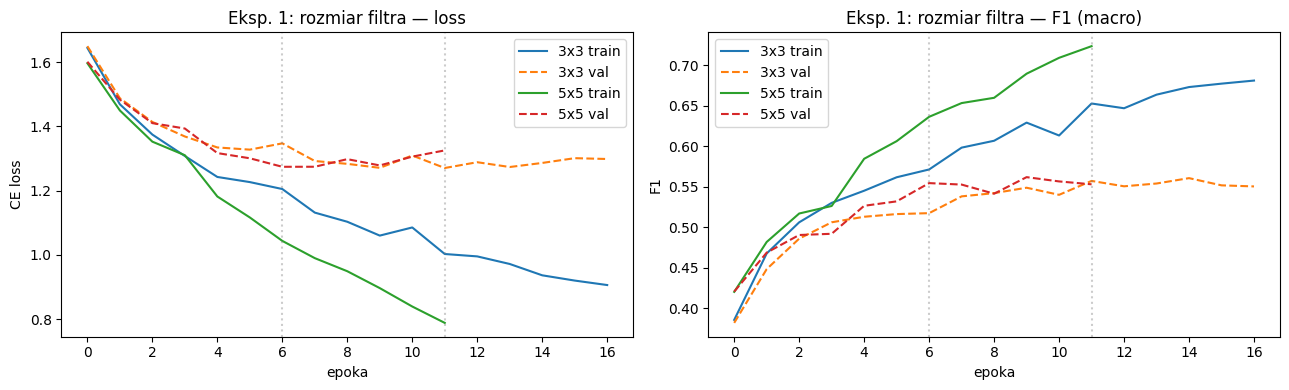

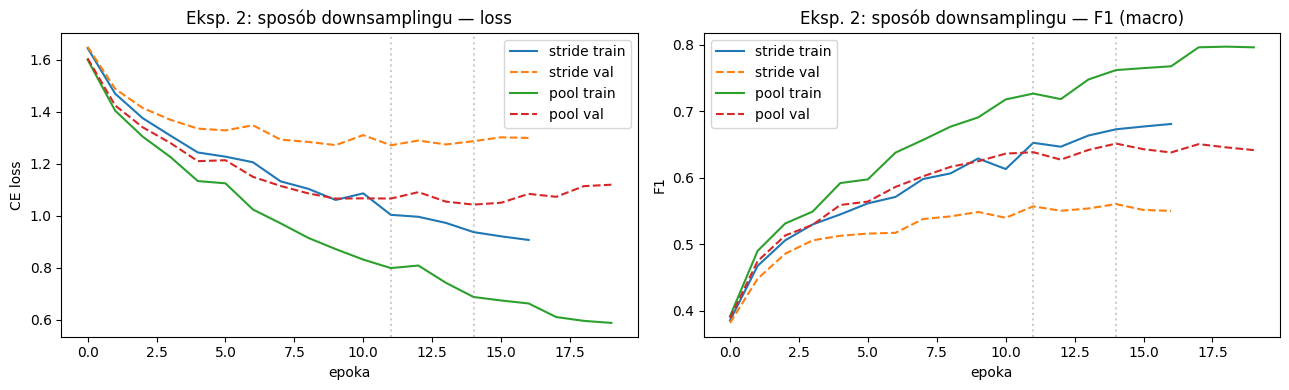

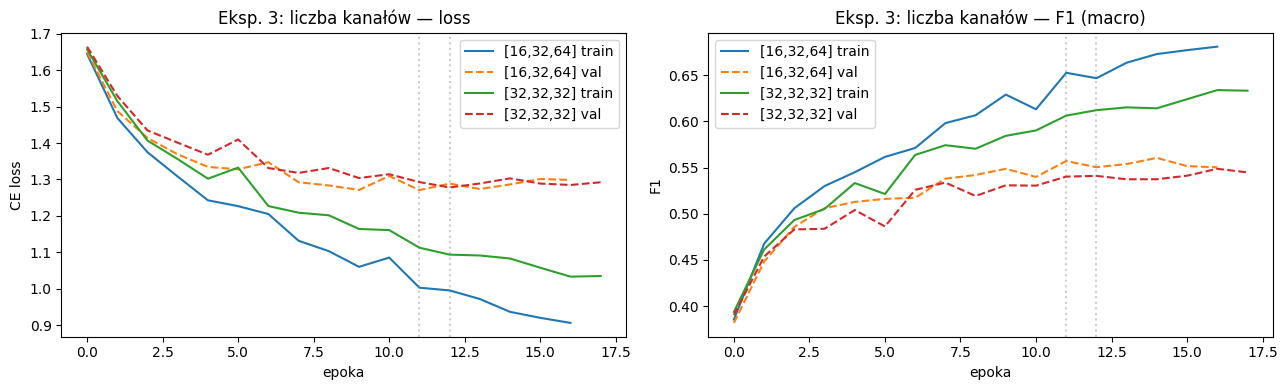


=== Podsumowanie: najlepsza epoka wg val_loss ===
  filtr 3x3 (baseline)            val_loss=1.271  F1=0.557  (epoka 11, łącznie 17 epok)
  filtr 5x5                       val_loss=1.274  F1=0.554  (epoka 6, łącznie 12 epok)
  downsampling: pool              val_loss=1.042  F1=0.652  (epoka 14, łącznie 20 epok)
  downsampling: stride            val_loss=1.271  F1=0.557  (epoka 11, łącznie 17 epok)
  kanały [16,32,64]               val_loss=1.271  F1=0.557  (epoka 11, łącznie 17 epok)
  kanały [32,32,32]               val_loss=1.278  F1=0.541  (epoka 12, łącznie 18 epok)


In [18]:
def plot_curves(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for h, label in zip(histories, labels):
        axes[0].plot(h["train_loss"], label=f"{label} train")
        axes[0].plot(h["val_loss"], label=f"{label} val", linestyle="--")
        axes[0].axvline(h["best_epoch"], color="gray", linestyle=":", alpha=0.4)
        axes[1].plot(h["train_f1"], label=f"{label} train")
        axes[1].plot(h["val_f1"], label=f"{label} val", linestyle="--")
        axes[1].axvline(h["best_epoch"], color="gray", linestyle=":", alpha=0.4)
    axes[0].set_title(f"{title} — loss")
    axes[0].set_xlabel("epoka"); axes[0].set_ylabel("CE loss"); axes[0].legend()
    axes[1].set_title(f"{title} — F1 (macro)")
    axes[1].set_xlabel("epoka"); axes[1].set_ylabel("F1"); axes[1].legend()
    plt.tight_layout()
    plt.show()


plot_curves([hist_k3, hist_k5], ["3x3", "5x5"], "Eksp. 1: rozmiar filtra")
plot_curves([hist_stride, hist_pool], ["stride", "pool"], "Eksp. 2: sposób downsamplingu")
plot_curves([hist_up, hist_same], ["[16,32,64]", "[32,32,32]"], "Eksp. 3: liczba kanałów")

print("\n=== Podsumowanie: najlepsza epoka wg val_loss ===")
rows = [
    ("filtr 3x3 (baseline)",     hist_k3),
    ("filtr 5x5",                hist_k5),
    ("downsampling: pool",       hist_pool),
    ("downsampling: stride",     hist_stride),
    ("kanały [16,32,64]",        hist_up),
    ("kanały [32,32,32]",        hist_same),
]
for name, h in rows:
    print(f"  {name:30s}  val_loss={h['best_val_loss']:.3f}  "
          f"F1={h['best_val_f1']:.3f}  (epoka {h['best_epoch']}, "
          f"łącznie {len(h['val_f1'])} epok)")
